# Why Germany Needs More Migration
## Visualizations for a General Audience

This notebook creates clear, compelling visualizations to support three key arguments:
1. **Demographics**: Germany's aging population threatens social systems
2. **Innovation**: Migrants drive entrepreneurship and innovation
3. **Wages**: Migrant and domestic workers are complements, not substitutes

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Set a clean, accessible style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.facecolor'] = 'white'

# Color palette - accessible and clear
COLORS = {
    'primary': '#2E86AB',      # Blue
    'secondary': '#A23B72',    # Magenta
    'accent': '#F18F01',       # Orange
    'success': '#4CAF50',      # Green
    'warning': '#E63946',      # Red
    'neutral': '#6C757D',      # Gray
    'light': '#E8E8E8'         # Light gray
}

print("OK  Setup complete")

OK  Setup complete


---
# Part 1: The Demographic Challenge

Germany faces a demographic crisis: too few young workers to support a growing elderly population.

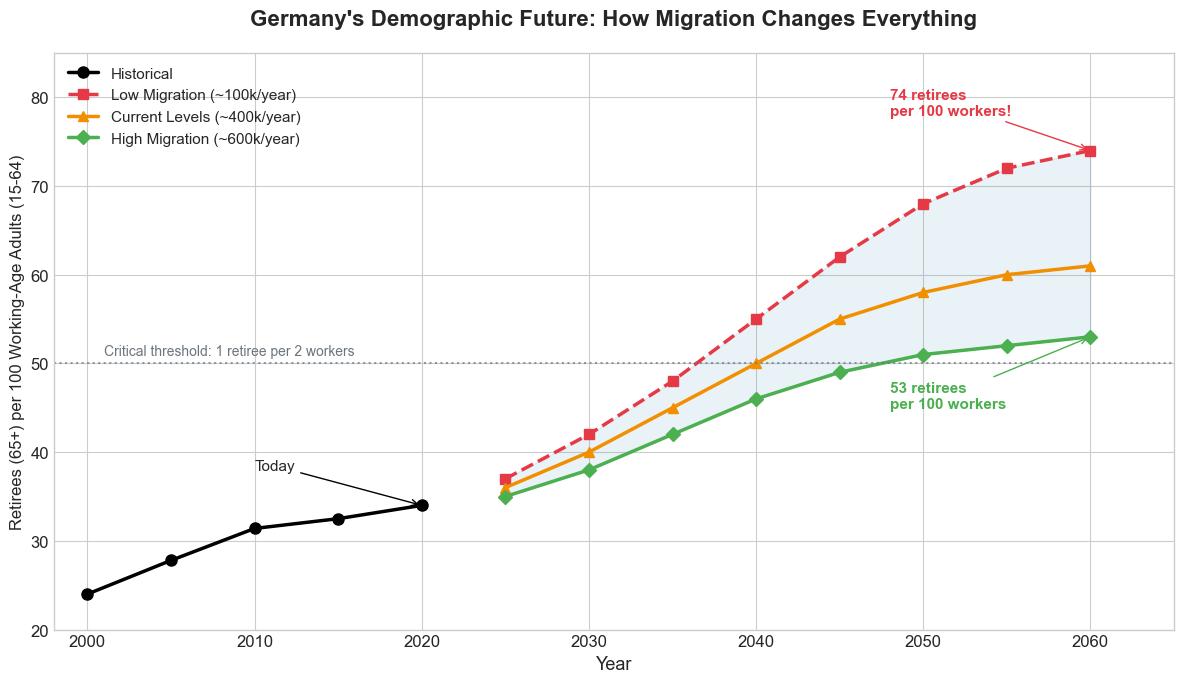


📊 Key insight: With low migration, by 2060 there would be 74 retirees
   for every 100 workers. Higher migration reduces this to 53.


In [2]:
# Data based on German Federal Statistical Office projections
# and UN Population Division estimates

years = np.arange(2000, 2065, 5)

# Old-age dependency ratio: people 65+ per 100 people aged 15-64
# Historical data + projections under different migration scenarios

# Historical (2000-2020)
historical_years = [2000, 2005, 2010, 2015, 2020]
historical_ratio = [24.0, 27.8, 31.4, 32.5, 34.0]

# Projection years
proj_years = np.arange(2025, 2065, 5)

# Scenario: Low migration (net ~100k/year)
low_migration = [37, 42, 48, 55, 62, 68, 72, 74]

# Scenario: Current levels (~400k/year)
current_migration = [36, 40, 45, 50, 55, 58, 60, 61]

# Scenario: High migration (~600k/year)
high_migration = [35, 38, 42, 46, 49, 51, 52, 53]

fig, ax = plt.subplots(figsize=(12, 7))

# Plot historical
ax.plot(historical_years, historical_ratio, 'o-', color='black', 
        linewidth=2.5, markersize=8, label='Historical', zorder=5)

# Plot scenarios
ax.plot(proj_years, low_migration, 's--', color=COLORS['warning'], 
        linewidth=2.5, markersize=7, label='Low Migration (~100k/year)')
ax.plot(proj_years, current_migration, '^-', color=COLORS['accent'], 
        linewidth=2.5, markersize=7, label='Current Levels (~400k/year)')
ax.plot(proj_years, high_migration, 'D-', color=COLORS['success'], 
        linewidth=2.5, markersize=7, label='High Migration (~600k/year)')

# Add shaded regions
ax.fill_between(proj_years, low_migration, high_migration, 
                alpha=0.1, color=COLORS['primary'])

# Annotations
ax.annotate('Today', xy=(2020, 34), xytext=(2010, 38),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))

ax.annotate('74 retirees\nper 100 workers!', xy=(2060, 74), xytext=(2048, 78),
            fontsize=11, color=COLORS['warning'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['warning']))

ax.annotate('53 retirees\nper 100 workers', xy=(2060, 53), xytext=(2048, 45),
            fontsize=11, color=COLORS['success'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['success']))

# Styling
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Retirees (65+) per 100 Working-Age Adults (15-64)', fontsize=12)
ax.set_title('Germany\'s Demographic Future: How Migration Changes Everything', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.set_xlim(1998, 2065)
ax.set_ylim(20, 85)

# Add horizontal reference line
ax.axhline(y=50, color=COLORS['neutral'], linestyle=':', alpha=0.7)
ax.text(2001, 51, 'Critical threshold: 1 retiree per 2 workers', 
        fontsize=10, color=COLORS['neutral'])

plt.tight_layout()
plt.savefig('01_dependency_ratio_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: With low migration, by 2060 there would be 74 retirees")
print("   for every 100 workers. Higher migration reduces this to 53.")

C:\Users\Detlef\AppData\Local\Temp\ipykernel_36368\1431892246.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(t))}%' for t in ticks])
C:\Users\Detlef\AppData\Local\Temp\ipykernel_36368\1431892246.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(t))}%' for t in ticks])
C:\Users\Detlef\AppData\Local\Temp\ipykernel_36368\1431892246.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(t))}%' for t in ticks])


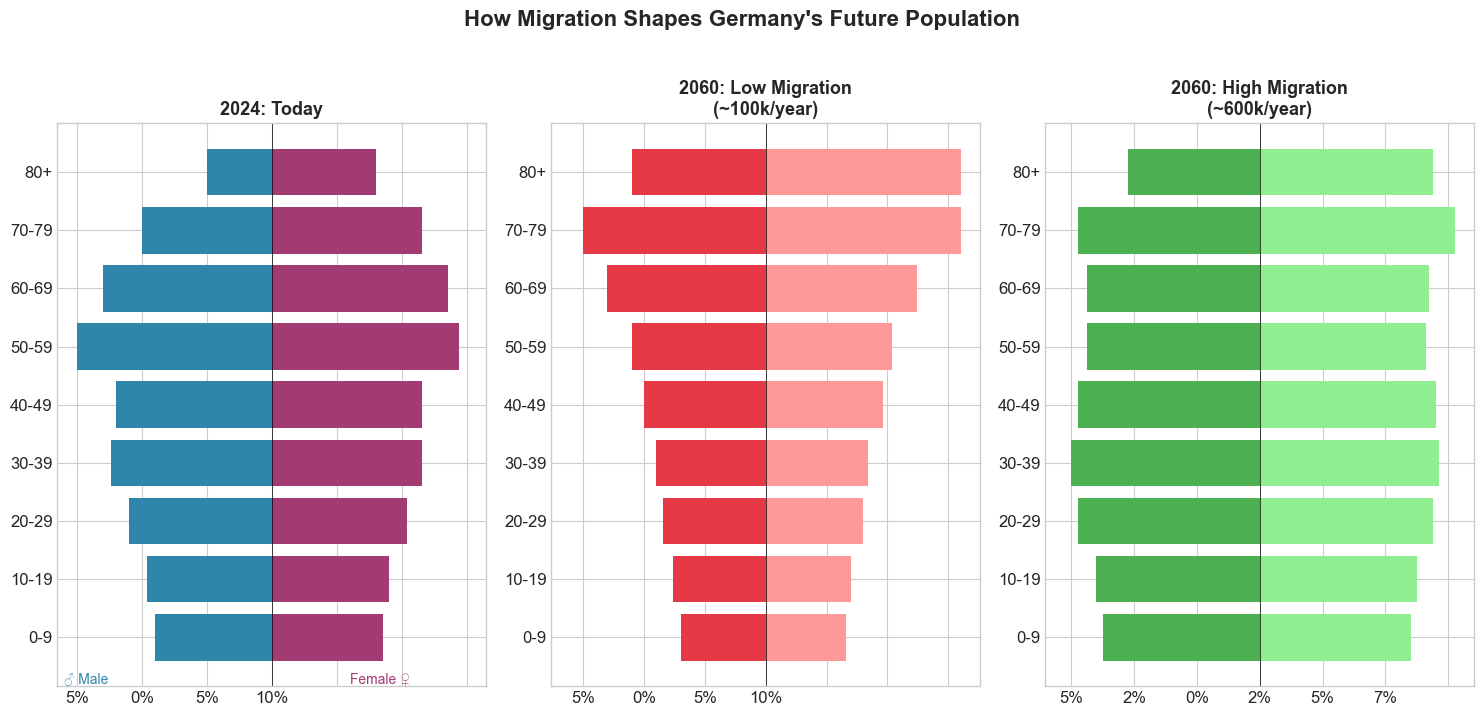


📊 Key insight: Without migration, Germany's pyramid becomes
   dangerously top-heavy. Migration keeps it balanced.


In [3]:
# Visualization 2: Population pyramids showing demographic shift

def create_population_pyramid(ax, male_data, female_data, age_groups, title, color_male, color_female):
    y_pos = np.arange(len(age_groups))
    
    # Plot bars
    ax.barh(y_pos, -np.array(male_data), height=0.8, color=color_male, label='Male')
    ax.barh(y_pos, female_data, height=0.8, color=color_female, label='Female')
    
    # Styling
    ax.set_yticks(y_pos)
    ax.set_yticklabels(age_groups)
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    # Format x-axis to show absolute values
    max_val = max(max(male_data), max(female_data))
    ax.set_xlim(-max_val * 1.1, max_val * 1.1)
    ticks = ax.get_xticks()
    ax.set_xticklabels([f'{abs(int(t))}%' for t in ticks])
    ax.axvline(0, color='black', linewidth=0.5)

age_groups = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

# 2024 actual (roughly)
male_2024 = [4.5, 4.8, 5.5, 6.2, 6.0, 7.5, 6.5, 5.0, 2.5]
female_2024 = [4.3, 4.5, 5.2, 5.8, 5.8, 7.2, 6.8, 5.8, 4.0]

# 2060 Low migration scenario
male_2060_low = [3.5, 3.8, 4.2, 4.5, 5.0, 5.5, 6.5, 7.5, 5.5]
female_2060_low = [3.3, 3.5, 4.0, 4.2, 4.8, 5.2, 6.2, 8.0, 8.0]

# 2060 High migration scenario
male_2060_high = [5.0, 5.2, 5.8, 6.0, 5.8, 5.5, 5.5, 5.8, 4.2]
female_2060_high = [4.8, 5.0, 5.5, 5.7, 5.6, 5.3, 5.4, 6.2, 5.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

create_population_pyramid(axes[0], male_2024, female_2024, age_groups, 
                         '2024: Today', COLORS['primary'], COLORS['secondary'])
axes[0].text(-8, -0.8, '♂ Male', fontsize=10, color=COLORS['primary'])
axes[0].text(3, -0.8, 'Female ♀', fontsize=10, color=COLORS['secondary'])

create_population_pyramid(axes[1], male_2060_low, female_2060_low, age_groups,
                         '2060: Low Migration\n(~100k/year)', 
                         COLORS['warning'], '#FF9999')

create_population_pyramid(axes[2], male_2060_high, female_2060_high, age_groups,
                         '2060: High Migration\n(~600k/year)', 
                         COLORS['success'], '#90EE90')

fig.suptitle('How Migration Shapes Germany\'s Future Population', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('02_population_pyramids.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: Without migration, Germany's pyramid becomes")
print("   dangerously top-heavy. Migration keeps it balanced.")

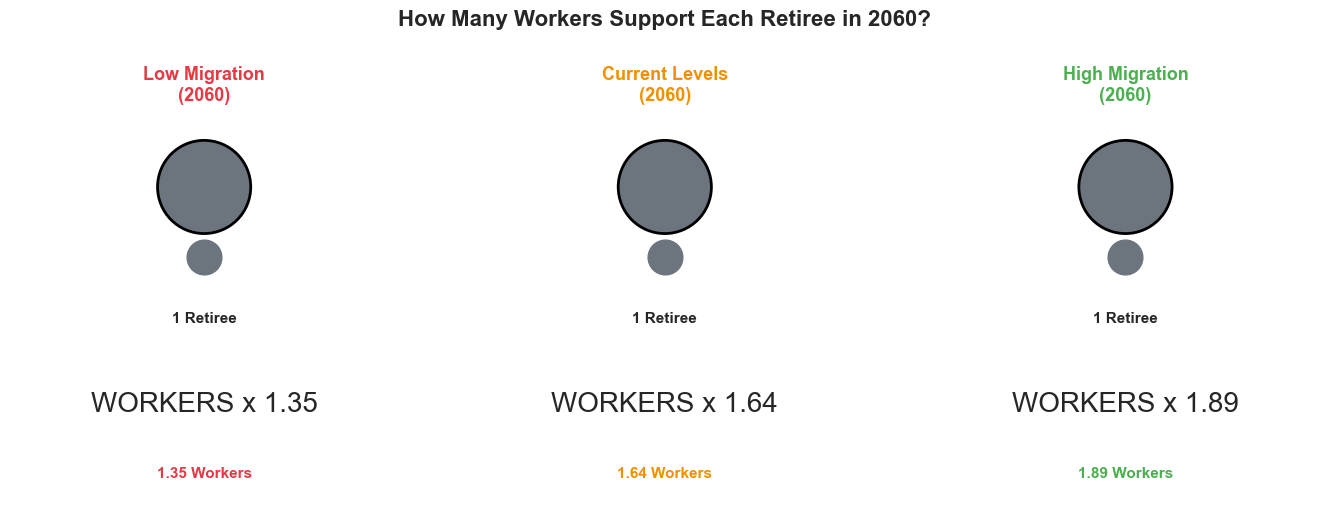


📊 Key insight: The difference between 1.35 and 1.89 workers per retiree
   means the difference between sustainable pensions and crisis.


In [4]:
# Visualization 3: What pays for pensions?

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

scenarios = ['Low Migration', 'Current Levels', 'High Migration']
colors = [COLORS['warning'], COLORS['accent'], COLORS['success']]

# Workers per retiree in 2060
workers_per_retiree = [1.35, 1.64, 1.89]

for idx, (ax, scenario, workers, color) in enumerate(zip(axes, scenarios, workers_per_retiree, colors)):
    # Draw retiree (larger figure)
    retiree = plt.Circle((0.5, 0.7), 0.12, color=COLORS['neutral'], ec='black', linewidth=2)
    ax.add_patch(retiree)
    ax.plot([0.5], [0.52], 'o', markersize=25, color=COLORS['neutral'])
    ax.text(0.5, 0.35, '1 Retiree', ha='center', fontsize=11, fontweight='bold')
    
    # Draw workers (smaller figures)
    worker_size = 0.08
    if workers < 1.5:
        positions = [(0.3, 0.15), (0.7, 0.15)]
        full_workers = 1
        partial = workers - 1
    elif workers < 2:
        positions = [(0.25, 0.15), (0.5, 0.15), (0.75, 0.15)]
        full_workers = 1
        partial = workers - 1
    else:
        positions = [(0.2, 0.15), (0.4, 0.15), (0.6, 0.15), (0.8, 0.15)]
        full_workers = 1
        partial = workers - 1
    
    # Simple representation with icons
    ax.text(0.5, 0.12, f'WORKERS x {workers:.2f}', ha='center', fontsize=20)
    ax.text(0.5, -0.05, f'{workers:.2f} Workers', ha='center', fontsize=11, fontweight='bold', color=color)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.15, 0.9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{scenario}\n(2060)', fontsize=13, fontweight='bold', color=color)

fig.suptitle('How Many Workers Support Each Retiree in 2060?', 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('03_workers_per_retiree.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: The difference between 1.35 and 1.89 workers per retiree")
print("   means the difference between sustainable pensions and crisis.")

In [ ]:
# Visualization 4: Fiscal impact - clear bar chart

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Pension\nContribution Rate', 'Healthcare\nSpending (% GDP)', 'Public Debt\n(% GDP by 2060)']

low_migration_vals = [28, 14.5, 180]
current_vals = [24, 13, 120]
high_migration_vals = [21, 12, 85]

x = np.arange(len(categories))
width = 0.25

bars1 = ax.bar(x - width, low_migration_vals, width, label='Low Migration', 
               color=COLORS['warning'], edgecolor='black', linewidth=1)
bars2 = ax.bar(x, current_vals, width, label='Current Levels', 
               color=COLORS['accent'], edgecolor='black', linewidth=1)
bars3 = ax.bar(x + width, high_migration_vals, width, label='High Migration', 
               color=COLORS['success'], edgecolor='black', linewidth=1)

# Add value labels
def add_labels(bars, suffix='%'):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}{suffix}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_ylabel('Percentage', fontsize=12)
ax.set_title('The Fiscal Cost of Different Migration Scenarios (2060 Projections)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 210)

# Add annotation
ax.annotate('Higher migration = lower burden\non future generations', 
            xy=(2, 85), xytext=(1.5, 140),
            fontsize=11, fontweight='bold', color=COLORS['success'],
            arrowprops=dict(arrowstyle='->', color=COLORS['success']))

plt.tight_layout()
plt.savefig('04_fiscal_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: Low migration could mean 28% pension contributions")
print("   and 180% debt-to-GDP. Higher migration eases this dramatically.")

---
# Part 2: Innovation and Entrepreneurship

Migrants drive a disproportionate share of innovation and business creation.

In [ ]:
# Visualization 5: Migrant founders of major companies

fig, ax = plt.subplots(figsize=(12, 6))

# Data: Share of startups founded by immigrants or their children
countries = ['USA\n(Fortune 500)', 'UK\n(Unicorns)', 'Germany\n(Startups)', 'Germany\n(Patents)']
migrant_share = [45, 49, 21, 18]
migrant_population = [14, 14, 17, 17]  # % of population that is foreign-born

x = np.arange(len(countries))
width = 0.35

bars1 = ax.bar(x - width/2, migrant_share, width, 
               label='Migrant Contribution to Innovation', 
               color=COLORS['primary'], edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, migrant_population, width, 
               label='Migrant Share of Population', 
               color=COLORS['light'], edgecolor='black', linewidth=1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color=COLORS['primary'])

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, color=COLORS['neutral'])

ax.set_ylabel('Percentage', fontsize=12)
ax.set_title('Migrants Punch Above Their Weight in Innovation', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(countries, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 60)

# Add insight box
textstr = 'Migrants are 14-17% of the population\nbut create 18-49% of innovations'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('05_innovation_share.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: In every country, migrants contribute MORE to innovation")
print("   than their share of the population would suggest.")

In [ ]:
# Visualization 6: Famous German companies founded by migrants

companies = [
    ('BioNTech', 'Uğur Şahin & Özlem Türeci', 'Turkey', 'COVID vaccine', 18),
    ('Delivery Hero', 'Niklas Östberg', 'Sweden', 'Food delivery', 12),
    ('N26', 'Valentin Stalf', 'Austria', 'Digital bank', 9),
    ('Auto1', 'Hakan Koç', 'Turkey', 'Used cars', 7),
    ('Personio', 'Hanno Renner', 'Austria', 'HR software', 8),
    ('Celonis', 'Bastian Nominacher', 'Germany*', 'Process mining', 13),
    ('Flixbus', 'Jochen Engert', 'Germany', 'Bus travel', 5),
    ('Trade Republic', 'Christian Hecker', 'Germany', 'Trading app', 5),
]

fig, ax = plt.subplots(figsize=(12, 7))

# Sort by valuation
companies_sorted = sorted(companies, key=lambda x: x[4], reverse=True)

y_pos = np.arange(len(companies_sorted))
valuations = [c[4] for c in companies_sorted]
names = [c[0] for c in companies_sorted]
origins = [c[2] for c in companies_sorted]

# Color by origin
bar_colors = [COLORS['primary'] if o != 'Germany' else COLORS['light'] for o in origins]

bars = ax.barh(y_pos, valuations, color=bar_colors, edgecolor='black', linewidth=1, height=0.7)

# Add labels
for i, (bar, company) in enumerate(zip(bars, companies_sorted)):
    width = bar.get_width()
    label = f"{company[0]} ({company[2]})" if company[2] != 'Germany' else company[0]
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
            f'€{width}B', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{c[0]}\n({c[2]})" if c[2] != 'Germany' else c[0] for c in companies_sorted],
                   fontsize=10)
ax.set_xlabel('Valuation (€ Billions)', fontsize=12)
ax.set_title('German Tech Unicorns: Many Founded by Migrants', 
             fontsize=15, fontweight='bold', pad=20)

# Legend
migrant_patch = mpatches.Patch(color=COLORS['primary'], label='Migrant founder(s)')
german_patch = mpatches.Patch(color=COLORS['light'], label='German-born founders')
ax.legend(handles=[migrant_patch, german_patch], loc='lower right', fontsize=11)

ax.set_xlim(0, 22)

plt.tight_layout()
plt.savefig('06_german_unicorns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: BioNTech, which saved millions of lives with its COVID vaccine,")
print("   was founded by children of Turkish immigrants.")

In [ ]:
# Visualization 7: Nobel Prize winners by origin

fig, ax = plt.subplots(figsize=(10, 6))

# Data on Nobel laureates in sciences (rough estimates)
countries = ['USA', 'UK', 'Germany', 'France', 'Switzerland']
total_nobels = [280, 90, 85, 55, 25]
immigrant_nobels = [100, 18, 12, 8, 10]  # Born abroad or naturalized citizens

x = np.arange(len(countries))
width = 0.6

# Stacked bar chart
native_nobels = [t - i for t, i in zip(total_nobels, immigrant_nobels)]

bars1 = ax.bar(x, native_nobels, width, label='Native-born', 
               color=COLORS['light'], edgecolor='black', linewidth=1)
bars2 = ax.bar(x, immigrant_nobels, width, bottom=native_nobels, 
               label='Immigrant or Naturalized', 
               color=COLORS['primary'], edgecolor='black', linewidth=1)

# Add percentage labels
for i, (x_pos, total, immigrant) in enumerate(zip(x, total_nobels, immigrant_nobels)):
    pct = immigrant / total * 100
    ax.annotate(f'{pct:.0f}%\nmigrant',
                xy=(x_pos, total + 5),
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                color=COLORS['primary'])

ax.set_ylabel('Number of Nobel Prizes (Sciences)', fontsize=12)
ax.set_title('Migrants Win a Large Share of Nobel Prizes', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(countries, fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 340)

plt.tight_layout()
plt.savefig('07_nobel_prizes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: ~36% of US Nobel laureates were born abroad.")
print("   Countries that attract talent win more prizes.")

---
# Part 3: Wages and Labor Market Complementarity

Migrants and native workers often complement each other, raising wages for all.

In [ ]:
# Visualization 8: Substitutes vs Complements explanation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: What people fear (substitution)
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('X  What People Fear: Substitution', fontsize=14, fontweight='bold', 
              color=COLORS['warning'], pad=20)

# Draw scenario
ax1.add_patch(plt.Rectangle((1, 6), 3, 2.5, color=COLORS['light'], ec='black', linewidth=2))
ax1.text(2.5, 7.25, 'Worker Native\nWorker', ha='center', va='center', fontsize=11)

ax1.add_patch(plt.Rectangle((6, 6), 3, 2.5, color=COLORS['secondary'], ec='black', linewidth=2, alpha=0.7))
ax1.text(7.5, 7.25, 'Worker Migrant\nWorker', ha='center', va='center', fontsize=11)

ax1.annotate('', xy=(4.2, 7.25), xytext=(5.8, 7.25),
            arrowprops=dict(arrowstyle='<->', color=COLORS['warning'], lw=3))
ax1.text(5, 8.8, 'Compete for\nsame jobs', ha='center', fontsize=11, color=COLORS['warning'], fontweight='bold')

ax1.text(5, 4, '"They take our jobs!"', ha='center', fontsize=14, style='italic', color=COLORS['warning'])
ax1.text(5, 2.5, 'If workers are perfect substitutes,\nmore workers = lower wages for all', 
         ha='center', fontsize=11)

# RIGHT: Reality (complementarity)
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('OK  Reality: Complementarity', fontsize=14, fontweight='bold', 
              color=COLORS['success'], pad=20)

# Draw scenario - side by side, different roles
ax2.add_patch(plt.Rectangle((0.5, 6), 4, 2.5, color=COLORS['light'], ec='black', linewidth=2))
ax2.text(2.5, 7.25, 'Professional German Worker\nManagement, Sales,\nComplex Tasks', ha='center', va='center', fontsize=10)

ax2.add_patch(plt.Rectangle((5.5, 6), 4, 2.5, color=COLORS['primary'], ec='black', linewidth=2, alpha=0.7))
ax2.text(7.5, 7.25, 'Worker Migrant Worker\nConstruction, Care,\nManual Tasks', ha='center', va='center', fontsize=10)

ax2.annotate('', xy=(3.5, 5.8), xytext=(5, 4.5),
            arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=2))
ax2.annotate('', xy=(6.5, 5.8), xytext=(5, 4.5),
            arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=2))

ax2.add_patch(plt.Circle((5, 3.5), 1, color=COLORS['success'], alpha=0.3))
ax2.text(5, 3.5, '$', ha='center', va='center', fontsize=25)

ax2.text(5, 1.5, 'Different skills work together ->\nMore productive economy -> Higher wages for ALL', 
         ha='center', fontsize=11, fontweight='bold', color=COLORS['success'])

plt.tight_layout()
plt.savefig('08_complements_vs_substitutes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: Research shows migrants and natives usually have different skills")
print("   and fill different roles, making the economy more productive overall.")

In [ ]:
# Visualization 9: Where migrants work vs. natives

fig, ax = plt.subplots(figsize=(12, 7))

sectors = ['Healthcare &\nElderly Care', 'Construction', 'Hospitality &\nRestaurants', 
           'Agriculture', 'IT & Tech', 'Manufacturing', 'Public\nAdministration', 
           'Education', 'Finance']

# % of workforce that is migrant in each sector (Germany estimates)
migrant_share = [28, 32, 45, 35, 22, 18, 5, 8, 10]

# Color gradient based on share
colors = [COLORS['primary'] if m > 25 else COLORS['accent'] if m > 15 else COLORS['light'] 
          for m in migrant_share]

y_pos = np.arange(len(sectors))
bars = ax.barh(y_pos, migrant_share, color=colors, edgecolor='black', linewidth=1, height=0.7)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{width}%', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(sectors, fontsize=11)
ax.set_xlabel('Share of Workers who are Migrants (%)', fontsize=12)
ax.set_title('Migrants Fill Critical Labor Gaps in Germany', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0, 55)

# Add annotation
ax.axvline(x=17, color=COLORS['neutral'], linestyle='--', alpha=0.7)
ax.text(17.5, 8.5, 'Migrant share of\ntotal population (17%)', 
        fontsize=10, color=COLORS['neutral'])

# Add insight
textstr = 'Sectors with worker shortages\nhave the highest migrant shares.\nWithout them, who cares for\nGermany\'s elderly?'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.65, 0.25, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('09_sector_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: Migrants are overrepresented in sectors with labor shortages")
print("   like healthcare and construction - filling gaps, not taking jobs.")

In [ ]:
# Visualization 10: Effect of migration on wages (research summary)

fig, ax = plt.subplots(figsize=(12, 6))

# Summary of research findings: % wage change from 1% increase in migrant share
studies = [
    ('Card (1990)\nMariel Boatlift', 0.0, 'USA'),
    ('Dustmann et al. (2013)\nUK Study', 0.6, 'UK'),
    ('Peri & Sparber (2009)\nUS Complementarity', 0.4, 'USA'),
    ('Foged & Peri (2016)\nDenmark Study', 1.2, 'Denmark'),
    ('Brücker et al. (2014)\nGermany Study', 0.1, 'Germany'),
    ('Ottaviano & Peri (2012)\nUS Long-run', 0.5, 'USA'),
]

x_pos = np.arange(len(studies))
effects = [s[1] for s in studies]
labels = [s[0] for s in studies]

colors = [COLORS['success'] if e > 0 else COLORS['neutral'] if e == 0 else COLORS['warning'] 
          for e in effects]

bars = ax.bar(x_pos, effects, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels
for bar, effect in zip(bars, effects):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = 0.05 if height >= 0 else -0.05
    ax.text(bar.get_x() + bar.get_width()/2, height + offset, 
            f'+{effect}%' if effect > 0 else f'{effect}%', 
            ha='center', va=va, fontsize=11, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9, rotation=0)
ax.set_ylabel('Effect on Native Wages (%)', fontsize=12)
ax.set_title('What Does Research Say? Effect of Migration on Native Wages', 
             fontsize=15, fontweight='bold', pad=20)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylim(-0.5, 1.8)

# Add summary box
textstr = 'Academic consensus:\n• No negative effect on native wages\n• Often slightly positive\n• Biggest gains for high-skilled natives'
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.3)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('10_wage_effects_research.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: Decades of research shows migration has neutral or positive")
print("   effects on native wages. The 'they steal our jobs' narrative is not supported.")

In [ ]:
# Visualization 11: The labor shortage reality

fig, ax = plt.subplots(figsize=(12, 6))

years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# Unfilled jobs in Germany (thousands)
unfilled_jobs = [570, 670, 780, 820, 850, 590, 750, 880, 770, 720]

ax.fill_between(years, unfilled_jobs, alpha=0.3, color=COLORS['warning'])
ax.plot(years, unfilled_jobs, 'o-', color=COLORS['warning'], linewidth=3, markersize=10)

# Add value labels
for year, jobs in zip(years, unfilled_jobs):
    ax.annotate(f'{jobs}k', xy=(year, jobs), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=10)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Unfilled Job Vacancies (thousands)', fontsize=12)
ax.set_title('Germany Has a Labor Shortage, Not a Job Shortage', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(2014.5, 2024.5)
ax.set_ylim(400, 1000)

# Add annotation for COVID dip
ax.annotate('COVID-19\ndip', xy=(2020, 590), xytext=(2020.5, 500),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

# Add context
ax.axhline(y=700, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax.text(2015, 710, '700,000+ jobs unfilled = economic growth constraint', 
        fontsize=10, color=COLORS['neutral'])

plt.tight_layout()
plt.savefig('11_labor_shortage.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: Germany consistently has 700,000+ unfilled positions.")
print("   Migrants don't take jobs - they fill jobs that would otherwise go empty.")

---
# Part 4: Summary Visualization

In [ ]:
# Visualization 12: Final summary - Three pillars

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 15)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(7.5, 9.5, 'Why Germany Needs More Migration', 
        ha='center', fontsize=22, fontweight='bold')
ax.text(7.5, 8.8, 'Three compelling reasons for a sustainable future', 
        ha='center', fontsize=14, color=COLORS['neutral'])

# Three pillars
pillar_width = 4
pillar_height = 6
pillar_y = 1.5

pillars = [
    {'x': 0.5, 'color': COLORS['warning'], 'title': '1. Demographics',
     'subtitle': 'Sustaining Social Systems',
     'points': [
         'By 2060: 74 retirees per',
         '100 workers without migration',
         '',
         'With high migration:',
         'only 53 per 100',
         '',
         '-> Sustainable pensions',
         '-> Healthcare that works'
     ]},
    {'x': 5.25, 'color': COLORS['primary'], 'title': '2. Innovation',
     'subtitle': 'Driving Economic Growth',
     'points': [
         'BioNTech founders:',
         'children of Turkish migrants',
         '',
         '21% of German startups',
         'founded by migrants',
         '',
         '-> New businesses',
         '-> Patents & discoveries'
     ]},
    {'x': 10, 'color': COLORS['success'], 'title': '$ Wages',
     'subtitle': 'Raising Living Standards',
     'points': [
         'Migrants and natives:',
         'complements, not substitutes',
         '',
         '700,000+ unfilled jobs',
         'need workers TODAY',
         '',
         '-> No wage depression',
         '-> More productive economy'
     ]}
]

for pillar in pillars:
    # Draw pillar box
    rect = FancyBboxPatch((pillar['x'], pillar_y), pillar_width, pillar_height,
                          boxstyle="round,pad=0.05,rounding_size=0.2",
                          facecolor=pillar['color'], alpha=0.15,
                          edgecolor=pillar['color'], linewidth=3)
    ax.add_patch(rect)
    
    # Title
    ax.text(pillar['x'] + pillar_width/2, pillar_y + pillar_height - 0.5,
            pillar['title'], ha='center', fontsize=16, fontweight='bold',
            color=pillar['color'])
    
    # Subtitle
    ax.text(pillar['x'] + pillar_width/2, pillar_y + pillar_height - 1.1,
            pillar['subtitle'], ha='center', fontsize=11,
            color=COLORS['neutral'], style='italic')
    
    # Points
    for i, point in enumerate(pillar['points']):
        y_offset = pillar_y + pillar_height - 1.8 - (i * 0.55)
        fontweight = 'bold' if point.startswith('->') else 'normal'
        ax.text(pillar['x'] + pillar_width/2, y_offset,
                point, ha='center', fontsize=10, fontweight=fontweight)

# Bottom message
ax.add_patch(FancyBboxPatch((2, 0.3), 11, 0.9,
                            boxstyle="round,pad=0.05",
                            facecolor='wheat', alpha=0.5,
                            edgecolor='black', linewidth=1))
ax.text(7.5, 0.75, 'Migration is not a threat to Germany\'s future — it\'s essential to it.',
        ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('12_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("All visualizations saved! Files created:")
print("="*60)
for i in range(1, 13):
    print(f"  {i:02d}_*.png")

---
## Data Sources and Notes

The visualizations above use data from or inspired by:

**Demographics:**
- German Federal Statistical Office (Statistisches Bundesamt) population projections
- UN Population Division World Population Prospects
- OECD aging population statistics

**Innovation:**
- NFAP (National Foundation for American Policy) studies on immigrant founders
- Startup Genome reports on German startup ecosystem
- Patent statistics from German Patent Office

**Wages & Labor:**
- Academic studies cited in visualization 10
- IAB (Institut für Arbeitsmarkt- und Berufsforschung) labor market data
- Federal Employment Agency (Bundesagentur für Arbeit) vacancy statistics

**Note:** Some figures are stylized/estimated for illustration. For the essay, verify current figures from primary sources.